# SSURGO Data Exploration

The purpose of thi notebook is to explore the [SSURGO soil database;](https://www.nrcs.usda.gov/resources/data-and-reports/soil-survey-geographic-database-ssurgo) figure out how to access it, what sort of data it contains, etc. It is an aggre

* [Data Access Web Serve Help](https://sdmdataaccess.nrcs.usda.gov/WebServiceHelp.aspx)
* [Some documentation](https://www.nrcs.usda.gov/resources/data-and-reports/ssurgo/stats2go-metadata) use this to figure out units of fields and whatnot
* [How to query](https://sdmdataaccess.nrcs.usda.gov/QueryHelp.aspx), can also try out queries and see results
* [NCSS Github, mostly R code](https://github.com/ncss-tech)

Here's a disambiguation of some of the entities involved as best as I can tell.
* Underlying dataset: SSURGO, the Soil Survey Geographic Database.
* Soil Data Mart: hosted database server where the SSURGO lives.
* Soil Data Access (SDA): This is the API.
* Web Soil Servey (WSS): This is a browser-based map interface. Reads from Soil Data Mart.
* SSURGO Portal: Windows desktop app that takes SSURGO downloads and loads them into a local SQLite database. Offline alternative to SDA, not necessary to use.
* STATSGO2: a generalized, coarser resolution dataset which also lives on Soil Data Mart and is queryable through the SDA API.

```
SSURGO (the data)
└── Soil Data Mart (the hosted database)
    ├── Web Soil Survey (browser UI)
    └── Soil Data Access (API)
        ├── post.rest
        ├── SOAP service
        └── WFS/WMS spatial services
```

[The query help page](https://sdmdataaccess.nrcs.usda.gov/QueryHelp.aspx) 

In [27]:
import requests
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.width', None)        # don't wrap output

In [28]:

def query_sda(sql):
    url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"
    payload = {"query": sql, "format": "json+columnname"}
    
    response = requests.post(url, data=payload)
    response.raise_for_status()
    
    if not response.text:
        raise ValueError("Empty response from SDA — check your SQL for errors")
    
    data = response.json()
    
    # The response wraps results in a 'Table' key (or 'Table1', 'Table2'... for multiple result sets)
    # First row is column names when using json+columnname
    table = data.get("Table", [])
    if not table:
        return pd.DataFrame()
    
    columns = table[0]
    rows = table[1:]
    return pd.DataFrame(rows, columns=columns)


# Sanity check — just fetch 5 map units
sql = "SELECT TOP 5 mukey, muname FROM mapunit"
df = query_sda(sql)
print(df)

   mukey                                                   muname
0  49456       Sarkar-McGilvery complex, 75 to 120 percent slopes
1  49457    Kupreanof-Tolstoi association, 5 to 35 percent slopes
2  49458   Kupreanof-Tolstoi association, 35 to 75 percent slopes
3  49459  Kupreanof-Tolstoi association, 75 to 100 percent slopes
4  49460        Liesnoi-Blaquirre complex, 5 to 35 percent slopes


In [29]:
# here we explore the table "muaggatt". First display what columns are actually present:
sql = "SELECT TOP 1 * FROM muaggatt"
df = query_sda(sql)
print("Num of columns: {}".format(len(df.columns.tolist())))
print(df.columns.tolist())

Num of columns: 40
['musym', 'muname', 'mustatus', 'slopegraddcp', 'slopegradwta', 'brockdepmin', 'wtdepannmin', 'wtdepaprjunmin', 'flodfreqdcd', 'flodfreqmax', 'pondfreqprs', 'aws025wta', 'aws050wta', 'aws0100wta', 'aws0150wta', 'drclassdcd', 'drclasswettest', 'hydgrpdcd', 'iccdcd', 'iccdcdpct', 'niccdcd', 'niccdcdpct', 'engdwobdcd', 'engdwbdcd', 'engdwbll', 'engdwbml', 'engstafdcd', 'engstafll', 'engstafml', 'engsldcd', 'engsldcp', 'englrsdcd', 'engcmssdcd', 'engcmssmp', 'urbrecptdcd', 'urbrecptwta', 'forpehrtdcp', 'hydclprs', 'awmmfpwwta', 'mukey']


In [30]:
# here we explore the table "component". First display what columns are actually present:
sql = "SELECT TOP 1 * FROM component"
df = query_sda(sql)
print("Num of columns: {}".format(len(df.columns.tolist())))
print(df.columns.tolist())

Num of columns: 122
['comppct_l', 'comppct_r', 'comppct_h', 'compname', 'compkind', 'majcompflag', 'otherph', 'localphase', 'slope_l', 'slope_r', 'slope_h', 'slopelenusle_l', 'slopelenusle_r', 'slopelenusle_h', 'runoff', 'tfact', 'wei', 'weg', 'erocl', 'earthcovkind1', 'earthcovkind2', 'hydricon', 'hydricrating', 'drainagecl', 'hydrologystatus', 'elev_l', 'elev_r', 'elev_h', 'aspectccwise', 'aspectrep', 'aspectcwise', 'geomdesc', 'albedodry_l', 'albedodry_r', 'albedodry_h', 'airtempa_l', 'airtempa_r', 'airtempa_h', 'map_l', 'map_r', 'map_h', 'reannualprecip_l', 'reannualprecip_r', 'reannualprecip_h', 'ffd_l', 'ffd_r', 'ffd_h', 'soiltempa_l', 'soiltempa_r', 'soiltempa_h', 'watertempa_l', 'watertempa_r', 'watertempa_h', 'nirrcapcl', 'nirrcapscl', 'nirrcapunit', 'irrcapcl', 'irrcapscl', 'irrcapunit', 'cropprodindex', 'constreeshrubgrp', 'wndbrksuitgrp', 'rsprod_l', 'rsprod_r', 'rsprod_h', 'foragesuitgrpid', 'wlgrain', 'wlgrass', 'wlherbaceous', 'wlshrub', 'wlconiferous', 'wlhardwood', 'wl

In [31]:
# here we explore the table "chorizon". First display what columns are actually present:
sql = "SELECT TOP 1 * FROM chorizon"
df = query_sda(sql)
print("Num of columns: {}".format(len(df.columns.tolist())))
print(df.columns.tolist())

Num of columns: 209
['hzname', 'desgndisc', 'desgnmaster', 'desgnmasterprime', 'desgnvert', 'hzdept_l', 'hzdept_r', 'hzdept_h', 'hzdepb_l', 'hzdepb_r', 'hzdepb_h', 'hzthk_l', 'hzthk_r', 'hzthk_h', 'texturerv', 'horztype', 'fragvoltot_l', 'fragvoltot_r', 'fragvoltot_h', 'fraggt10_l', 'fraggt10_r', 'fraggt10_h', 'frag3to10_l', 'frag3to10_r', 'frag3to10_h', 'huartvoltot_l', 'huartvoltot_r', 'huartvoltot_h', 'sieveno4_l', 'sieveno4_r', 'sieveno4_h', 'sieveno10_l', 'sieveno10_r', 'sieveno10_h', 'sieveno40_l', 'sieveno40_r', 'sieveno40_h', 'sieveno200_l', 'sieveno200_r', 'sieveno200_h', 'sandtotal_l', 'sandtotal_r', 'sandtotal_h', 'sandvc_l', 'sandvc_r', 'sandvc_h', 'sandco_l', 'sandco_r', 'sandco_h', 'sandmed_l', 'sandmed_r', 'sandmed_h', 'sandfine_l', 'sandfine_r', 'sandfine_h', 'sandvf_l', 'sandvf_r', 'sandvf_h', 'silttotal_l', 'silttotal_r', 'silttotal_h', 'siltco_l', 'siltco_r', 'siltco_h', 'siltfine_l', 'siltfine_r', 'siltfine_h', 'claytotal_l', 'claytotal_r', 'claytotal_h', 'claysized

## A word about the data

The data is organized into *map units*. These are polygons on the map. You can see them at the [Web Soil Survey](https://websoilsurvey.nrcs.usda.gov/app/WebSoilSurvey.aspx) but it's easier to do [here](https://mapscaping.com/us-soil-map/#lat=39.47357&lng=-98.60590&z=12&op=0.75&lyr=mapunits) since you don't have to define an Area Of Interest first. These polygons are pretty "round" I think because they're supposed to replicate natural geographic features.

The size of each map unit varies from a few acres (where soil is complex and highly variable) to hundreds of acres in areas with uniform soil (midwest for instance).

*muaggatt*
This table aggreggates data to the level of map unit.

*component*
This table lists the map unit components identified in the reference map unit, that is, it lists different amounts of component soil present in a single map unit.

A concrete example: a map unit called "Clarion-Nicollet complex" in Iowa might have:

- Clarion soil series — 55% of the polygon
- Nicollet soil series — 35% of the polygon
- Webster soil series — 10% of the polygon

Each of these components has its own drainage class, pH, organic matter, texture etc.

*chorizon*
I think this is "component horizon", I'm not sure. Horizons are vertical sublayers of a single component. 
```
Component (a soil type, e.g. "Clarion loam")
├── Horizon 1: 0–25cm   (the "A" horizon, topsoil)
├── Horizon 2: 25–61cm  (the "B" horizon, subsoil)
├── Horizon 3: 61–102cm (the "C" horizon, parent material)
└── Horizon 4: 102cm+   (bedrock or restrictive layer)
```
Each horizon in the `chorizon` table has its own row, linked back to its component via `cokey`. The key columns that define a horizon are:

- `hzdept_r` — top depth in cm
- `hzdepb_r` — bottom depth in cm
- `hzname` — the horizon designation (A, B, C, etc.)

And then the soil properties measured **at that depth**:
- `om_r` — organic matter
- `ph1to1h2o_r` — pH
- `sandtotal_r`, `silttotal_r`, `claytotal_r` — texture
- `awc_r` — available water capacity
- `dbthirdbar_r` — bulk density

The `_r` suffix on each of these means "representative value". SSURGO stores low, representative, and high values for most properties, so you'll see values referenced in (LOW= x, RV=y, HIGH=z) format in the documentation. This is what that means.

## Getting all data from a state

Now we run an experiment to get all the `muaggatt` data from a single state. We've chosen Iowa.

In [32]:
# get all Iowa survey area symbols
sql = "SELECT areasymbol, areaname FROM legend WHERE areasymbol LIKE 'IA%'"
areas = query_sda(sql)
print(areas)

   areasymbol                areaname
0       IA001      Adair County, Iowa
1       IA005  Allamakee County, Iowa
2       IA007  Appanoose County, Iowa
3       IA009    Audubon County, Iowa
4       IA011     Benton County, Iowa
..        ...                     ...
94      IA185      Wayne County, Iowa
95      IA029       Cass County, Iowa
96      IA059  Dickinson County, Iowa
97      IA195      Worth County, Iowa
98      IA015      Boone County, Iowa

[99 rows x 2 columns]


In [33]:
# get data from all Iowa survey areas
sql = """
SELECT
    l.areasymbol,
    maa.*
FROM mapunit mu
JOIN muaggatt maa ON mu.mukey = maa.mukey
JOIN legend l ON mu.lkey = l.lkey
WHERE l.areasymbol LIKE 'IA%'
"""
df = query_sda(sql)
print(df.columns.tolist())  # see real column names
print(df.head())

['areasymbol', 'musym', 'muname', 'mustatus', 'slopegraddcp', 'slopegradwta', 'brockdepmin', 'wtdepannmin', 'wtdepaprjunmin', 'flodfreqdcd', 'flodfreqmax', 'pondfreqprs', 'aws025wta', 'aws050wta', 'aws0100wta', 'aws0150wta', 'drclassdcd', 'drclasswettest', 'hydgrpdcd', 'iccdcd', 'iccdcdpct', 'niccdcd', 'niccdcdpct', 'engdwobdcd', 'engdwbdcd', 'engdwbll', 'engdwbml', 'engstafdcd', 'engstafll', 'engstafml', 'engsldcd', 'engsldcp', 'englrsdcd', 'engcmssdcd', 'engcmssmp', 'urbrecptdcd', 'urbrecptwta', 'forpehrtdcp', 'hydclprs', 'awmmfpwwta', 'mukey']
  areasymbol  musym  \
0      IA003     54   
1      IA003  469C2   
2      IA003  470D2   
3      IA003   545B   
4      IA003   569C   

                                                              muname mustatus  \
0  Zook silty clay loam, 0 to 2 percent slopes, occasionally flooded     None   
1      Lamoni-Clarinda-Shelby complex, 5 to 9 percent slopes, eroded     None   
2              Lamoni-Shelby complex, 9 to 14 percent slopes, ero

In [34]:
df.head()

,areasymbol,musym,muname,mustatus,slopegraddcp,slopegradwta,brockdepmin,wtdepannmin,wtdepaprjunmin,flodfreqdcd,flodfreqmax,pondfreqprs,aws025wta,aws050wta,aws0100wta,aws0150wta,drclassdcd,drclasswettest,hydgrpdcd,iccdcd,iccdcdpct,niccdcd,niccdcdpct,engdwobdcd,engdwbdcd,engdwbll,engdwbml,engstafdcd,engstafll,engstafml,engsldcd,engsldcp,englrsdcd,engcmssdcd,engcmssmp,urbrecptdcd,urbrecptwta,forpehrtdcp,hydclprs,awmmfpwwta,mukey
0,IA003,54,"Zook silty clay loam, 0 to 2 percent slopes, occasionally flooded",None,1,1,NaN,0,0,Occasional,Occasional,5,5.39,10.64,17.06,26.26,Poorly drained,Poorly drained,D,NaN,100,2,95,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Poor,Poor,Very limited,1,Erosion hazard slight,100,1,1711846
1,IA003,469C2,"Lamoni-Clarinda-Shelby complex, 5 to 9 percent slopes, eroded",None,7,6.9,NaN,0,0,None,None,0,4.31,7.5,14.61,21.75,Somewhat poorly drained,Poorly drained,D,NaN,100,3,60,Very limited,Very limited,Somewhat limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Poor,Poor,Very limited,0.763,Erosion hazard moderate,35,0.859,1711851
2,IA003,470D2,"Lamoni-Shelby complex, 9 to 14 percent slopes, eroded",None,12,11.8,NaN,30,30,None,None,0,4.04,7.26,14.62,21.92,Somewhat poorly drained,Somewhat poorly drained,D,NaN,100,4,55,Very limited,Very limited,Somewhat limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Poor,Poor,Very limited,0.571,Erosion hazard severe,10,0.818,1711853
3,IA003,545B,"Zook-Ely-Gullied land complex, 2 to 5 percent slopes",None,4,3.9,NaN,0,0,None,None,0,4.85,9.43,17.1,26.35,Poorly drained,Poorly drained,D,NaN,100,2,80,Very limited,Very limited,Not rated,Very limited,Very limited,Not rated,Very limited,Very limited,Very limited,Very limited,Poor,Not rated,Very limited,0.941,Erosion hazard moderate,45,0.956,1711854
4,IA003,569C,"Nira-Clearfield complex, 5 to 9 percent slopes",None,7,6.7,NaN,0,0,None,None,0,5.36,10.23,19.55,28.69,Moderately well drained,Poorly drained,C,NaN,100,3,95,Somewhat limited,Very limited,Somewhat limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Very limited,Poor,Poor,Somewhat limited,0.484,Erosion hazard moderate,40,1,1711855


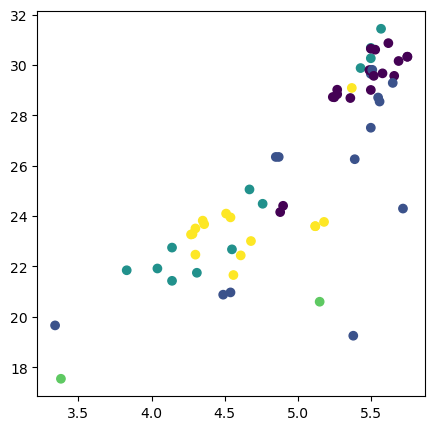

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# get available water storage 0-25 cm and 0-150 cm data
x = pd.to_numeric(df[df.areasymbol == "IA003"]["aws025wta"], errors="coerce")
y = pd.to_numeric(df[df.areasymbol == "IA003"]["aws0150wta"], errors="coerce")

# create color codes based on drainage class dominant conditions
cats = df[df.areasymbol == "IA003"]["drclassdcd"].astype("category")
color_codes = cats.cat.codes # integer code per category

# plot data
fig, ax = plt.subplots(1 , 1, figsize = (5,5))
ax.scatter(x,y, c=color_codes)
plt.show()

## The hierarchy of area size
```
Area Symbol (areasymbol)
└── Map Units (mukey) — many per survey area
    └── Components — many per map unit
        └── Horizons — many per component
```

## Data pertaining to actual soil qualities

**The three explored above:**

- chorizon — the primary quantitative data table: texture, organic matter, pH, bulk density, CEC, salinity, water content, erodibility, and more, all at the horizon level
- component — component-level properties including drainage class, slope, and land capability
- muaggatt — pre-aggregated map unit level summaries

**Additional horizon-level tables that extend chorizon:**

- chconsistence — soil physical behavior: rupture resistance, stickiness, plasticity. Relevant to tillage and compaction questions
- chfrags — rock fragment content by size and kind, affects root penetration and water movement
- chpores — pore size, shape and continuity, directly relevant to water infiltration and drainage
- chstruct — soil structure (grade, size, type of aggregates), affects aeration and root growth
- chtext — free-text notes written by the soil scientist at the horizon level, qualitative observations that don't fit neatly into columns

**Component-level tables:**

- cosoilmoist — seasonal soil moisture status by depth and month, important for drainage and irrigation questions
- codiagfeatures — diagnostic soil features like argillic horizons or fragipans that affect root penetration and water movement
- corestrictions — restrictive layers (hardpan, bedrock, etc.) that limit rooting depth, highly relevant to productivity questions
- cocropyld — crop yield estimates by component, directly useful for your productivity questions
- coeplants — ecological plant communities associated with each component

**The three I think are most useful:** 
- `chorizon`: most physical characteristics of the soil
- `corestrictions`: says stuff about the physical limits of productivity
- `cocropyld`: NRCS's yield estimates per component

In [37]:
sql = """SELECT TOP 5 * FROM cocropyld"""
dftest = query_sda(sql)
print(dftest.columns.tolist())  # see real column names
print(dftest.head())
print(dftest.columns)

['cropname', 'yldunits', 'nonirryield_l', 'nonirryield_r', 'nonirryield_h', 'irryield_l', 'irryield_r', 'irryield_h', 'cropprodindex', 'vasoiprdgrp', 'cokey', 'cocropyldkey']
        cropname yldunits nonirryield_l nonirryield_r nonirryield_h  \
0   Buffel grass      AUM          None             5          None   
1       Avocados    Boxes          None           535          None   
2     Pigeonpeas      Cwt          None            10          None   
3  Green peppers     Tons          None           NaN          None   
4       Tomatoes     Tons          None           NaN          None   

  irryield_l irryield_r irryield_h cropprodindex vasoiprdgrp     cokey  \
0       None        NaN       None          None        None  27626831   
1       None        NaN       None          None        None  27626831   
2       None        NaN       None          None        None  27626831   
3       None          8       None          None        None  27626831   
4       None         10     

In [ ]:
import requests
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.width', None)        # don't wrap output

In [ ]:
# this is a method for querying the SDA with a SQL method and returning the result as a dataframe
def query_sda(sql):
    url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"
    payload = {"query": sql, "format": "json+columnname"}
    
    response = requests.post(url, data=payload)
    response.raise_for_status()
    
    if not response.text:
        raise ValueError("Empty response from SDA — check your SQL for errors")
    
    data = response.json()
    
    # The response wraps results in a 'Table' key (or 'Table1', 'Table2'... for multiple result sets)
    # First row is column names when using json+columnname
    table = data.get("Table", [])
    if not table:
        return pd.DataFrame()
    
    columns = table[0]
    rows = table[1:]
    return pd.DataFrame(rows, columns=columns)


# Sanity check — just fetch 5 map units
sql = "SELECT TOP 5 mukey, muname FROM mapunit"
df = query_sda(sql)
print(df)

   mukey                                                   muname
0  49456       Sarkar-McGilvery complex, 75 to 120 percent slopes
1  49457    Kupreanof-Tolstoi association, 5 to 35 percent slopes
2  49458   Kupreanof-Tolstoi association, 35 to 75 percent slopes
3  49459  Kupreanof-Tolstoi association, 75 to 100 percent slopes
4  49460        Liesnoi-Blaquirre complex, 5 to 35 percent slopes


In [ ]:
def get_location_data_from_point(lon, lat):
    sql = f"""
    SELECT mu.mukey, mu.muname, l.areasymbol
    FROM mapunit mu
    JOIN legend l ON mu.lkey = l.lkey
    WHERE mu.mukey IN (
        SELECT * FROM SDA_Get_Mukey_from_intersection_with_WktWgs84(
            'POINT({lon} {lat})'
        )
    )
    """
    return query_sda(sql)

# Des Moines, Iowa
result = get_location_data_from_point(-93.6250, 41.5868)
print(result)

    mukey      muname areasymbol
0  412895  Urban land      IA153


In [ ]:
sql = """SELECT TOP 5 * FROM cocropyld"""
dftest = query_sda(sql)
print(dftest.columns.tolist())  # see real column names
print(dftest.head())
print(dftest.columns)

['cropname', 'yldunits', 'nonirryield_l', 'nonirryield_r', 'nonirryield_h', 'irryield_l', 'irryield_r', 'irryield_h', 'cropprodindex', 'vasoiprdgrp', 'cokey', 'cocropyldkey']
        cropname yldunits nonirryield_l nonirryield_r nonirryield_h  \
0   Buffel grass      AUM          None             5          None   
1       Avocados    Boxes          None           535          None   
2     Pigeonpeas      Cwt          None            10          None   
3  Green peppers     Tons          None           NaN          None   
4       Tomatoes     Tons          None           NaN          None   

  irryield_l irryield_r irryield_h cropprodindex vasoiprdgrp     cokey  \
0       None        NaN       None          None        None  27626831   
1       None        NaN       None          None        None  27626831   
2       None        NaN       None          None        None  27626831   
3       None          8       None          None        None  27626831   
4       None         10     

In [ ]:
# get all relevant tables associated to the map unit containing the specified point
# Currently gets
#   - crop data from cocropyld
#   - horizons data from chorizons
#   - restrictions data from corestrictions
def get_tables_from_point(lon, lat):
    mukey = get_location_data_from_point(lon, lat).iloc[0]["mukey"]

    # crop data 
    crop_sql = f"""
        SELECT co.compname, co.comppct_r, cc.*
        FROM component co
        JOIN cocropyld cc ON co.cokey = cc.cokey
        WHERE co.mukey = '{mukey}'"""

    # horizons
    horizons_sql = f"""
        SELECT co.compname, co.comppct_r, ch.*
        FROM component co
        JOIN chorizon ch ON co.cokey = ch.cokey
        WHERE co.mukey = '{mukey}'"""

    # Restrictions data
    restrictions_sql = f"""
        SELECT co.compname, co.comppct_r, cr.*
        FROM component co
        JOIN corestrictions cr ON co.cokey = cr.cokey
        WHERE co.mukey = '{mukey}'"""
    return query_sda(crop_sql), query_sda(horizons_sql), query_sda(restrictions_sql)

lon, lat = -93.6250, 41.5868
print(get_location_data_from_point(lon, lat).iloc[0]["mukey"])
print(get_tables_from_point(lon, lat))

412895
(Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [])


In [ ]:
import plotly.express as px
import pandas as pd

def plot_point(lat, lon):
    df = pd.DataFrame({"lat": [lat], "lon": [lon]})
    fig = px.scatter_map(df, lat="lat", lon="lon", zoom=13)
    fig.show()

plot_point(41.5868, -93.6250)

In [ ]:
import folium

def plot_point(lat, lon, zoom=13):
    m = folium.Map(location=[lat, lon], zoom_start=zoom)
    folium.Marker([lat, lon]).add_to(m)
    return m

m = plot_point(41.5868, -93.6250)
m  # renders inline in Jupyter

In [3]:
import sda_utils as sda

lon, lat = -93.647713, 42.774576
print(sda.get_location_data_from_point(lat, lon))
crop, horizon, restriction = sda.get_tables_from_point(lat, lon)
print(crop)
print(horizon)

     mukey                                    muname areasymbol
0  2835033  Webster clay loam, 0 to 2 percent slopes      IA197
2835033
Empty DataFrame
Columns: []
Index: []
    compname comppct_r hzname desgndisc desgnmaster desgnmasterprime  \
0    Webster        85     Cg      None           C             None   
1    Webster        85     Bg      None           B             None   
2    Webster        85     Ap      None           A             None   
3    Webster        85      A      None           A             None   
4   Nicollet         5      C      None           C             None   
5   Nicollet         5     Bg      None           B             None   
6   Nicollet         5     Ap      None           A             None   
7   Nicollet         5      A      None           A             None   
8   Canisteo         2     Cg      None           C             None   
9   Canisteo         2     AB      None          AB             None   
10  Canisteo         2      A     

In [ ]:
print(sda.summarize_crop_yields(crop))

                        yldunits  nonirryield_r irryield_r
cropname                                                  
Alfalfa hay                 Tons          13.64          0
Caucasian bluestem          Tons          25.70          0
Common bermudagrass         Tons          25.35          0
Corn                          Bu           0.00          0
Orchardgrass-red clover     Tons          25.05          0
Tall fescue                 Tons          26.60          0
Warm season grasses         Tons          32.40          0


In [8]:
sql = """SELECT DISTINCT mrulename FROM cointerp
JOIN component ON cointerp.cokey = component.cokey
JOIN mapunit ON component.mukey = mapunit.mukey
JOIN legend ON mapunit.lkey = legend.lkey
WHERE legend.areasymbol LIKE 'IA%'
ORDER BY mrulename"""

sda.query_sda(sql)

,mrulename
0,AGR - Industrial Hemp for Fiber and Seed Production
1,AWM - Irrigation Disposal of Wastewater
2,AWM - Land Application of Municipal Sewage Sludge
3,AWM - Manure and Food Processing Waste
4,AWM - Overland Flow Process Treatment of Wastewater
...,...
114,WMS - Pond Reservoir Area
115,"WMS - Subsurface Water Management, Outflow Quality"
116,"WMS - Subsurface Water Management, System Installation"
117,"WMS - Subsurface Water Management, System Performance"
